In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [4]:
# Step 1: Data Loading and Cleaning
import pandas as pd

# Read Excel files
df_customer = pd.read_excel("Customer_Information_2025_English.xlsx")
df_expenditure = pd.read_excel("Expenditure_Information_2025_English.xlsx")

# Clean up the expense period (capitalize + strip spaces)
df_expenditure['Statement Period'] = df_expenditure['Statement Period'].astype(str).str.strip().str.capitalize()

# Standardize the expense type (lowercase + strip spaces)
df_expenditure['Expenditure Type'] = df_expenditure['Expenditure Type'].astype(str).str.strip().str.lower()

# Convert expense amounts to numeric (safe against corrupted data)
df_expenditure['Expenditure Amount'] = pd.to_numeric(df_expenditure['Expenditure Amount'], errors='coerce').fillna(0)

# Normalize all column names to remove spaces (as a precaution)
df_customer.columns = df_customer.columns.str.strip()
df_expenditure.columns = df_expenditure.columns.str.strip()

# This step strengthens the data structure, reduces the risk of errors in later processes, and is quite valuable from a learning perspective.

In [5]:
df_customer.head()

,IAB (Customer No),Year of Birth,Monthly Income,Educational Status,Marital Status,Gender,Employment Status,Owns a House?,Owns a Car?,Is İşcep Installed?,Has SMS Communication Permission?,Has E-mail Communication Permission?
0,100000,1990,28500,Below High School,Single,Male,Freelance,0,1,0,0,1
1,100001,1953,29500,Undergraduate,Single,Female,Civil Servant,0,0,1,1,0
2,100002,1999,31000,High School,Single,Female,Worker,1,0,1,1,1
3,100003,1959,185000,Postgraduate,Married,Female,Civil Servant,0,0,0,0,1
4,100004,1962,32000,High School,Single,Female,Civil Servant,1,1,1,0,0


In [6]:
df_expenditure.head()

,IAB (Customer No),KKR No.,Statement Period,Expenditure Type,Expenditure Amount
0,100000,4205 3037 6098 5126,June,electronics,0
1,100000,4205 3037 6098 5126,June,market,0
2,100000,4205 3037 6098 5126,June,other,0
3,100000,4205 3037 6098 5126,June,clothing,14171
4,100000,4205 3037 6098 5126,June,tourism,2917


In [7]:
# Step 2: Identifying Categorical Variable Values

# Education Status (in df_customer)
print("Educational Status:", df_customer['Educational Status'].unique())

# Employment Status (in df_customer)
print("Employment Status:", df_customer['Employment Status'].unique())

# Billing Period (in df_expenditure)
print("Statement Period:", df_expenditure['Statement Period'].unique())

# Spending Type (in df_expenditure)
print("Expenditure Type:", df_expenditure['Expenditure Type'].unique())

Educational Status: ['Below High School' 'Undergraduate' 'High School' 'Postgraduate']
Employment Status: ['Freelance' 'Civil Servant' 'Worker' 'Retired']
Statement Period: ['June' 'July' 'August']
Expenditure Type: ['electronics' 'market' 'other' 'clothing' 'tourism' 'automotive'
 'cosmetics' 'cash withdrawal' 'education' 'furniture' 'travel'
 'white goods' 'fuel' 'tax payments']


In [8]:
# Step 3: Create and Summarize Spend Groups Based on Customers

# Let's group the expenditure types (resistant to spaces, uppercase letters, variations)
def expenditure_group(tur):
    tur = str(tur).strip().lower()
    if 'tourism' in tur:
        return 'tourism'
    elif 'travel' in tur:
        return 'travel'
    else:
        return 'other'

# New column: Spending Group
df_expenditure['Expenditure Group'] = df_expenditure['Expenditure Type'].apply(expenditure_group)

# Calculate the number of months spent for each customer
month_numbers = (
    df_expenditure
    .groupby('IAB (Customer No)')['Statement Period']
    .nunique()
    .reset_index()
    .rename(columns={'Statement Period': 'Month_Number'})
)

# Calculate the total amount of each spending group based on the customer
df_expenditure_summary = (
    df_expenditure
    .groupby(['IAB (Customer No)', 'Expenditure Group'])['Expenditure Amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Add possible missing groups (as columns)
for col in ['tourism', 'travel', 'other']:
    if col not in df_expenditure_summary.columns:
        df_expenditure_summary[col] = 0

# Merge with the number of months → to convert to average
df_expenditure_summary = df_expenditure_summary.merge(month_numbers, on='IAB (Customer No)', how='left')

# Calculate averages
df_expenditure_summary['tourism'] = df_expenditure_summary['tourism'] / df_expenditure_summary['Month_Number']
df_expenditure_summary['travel'] = df_expenditure_summary['travel'] / df_expenditure_summary['Month_Number']
df_expenditure_summary['other'] = df_expenditure_summary['other'] / df_expenditure_summary['Month_Number']

# Keep or remove the Month_Number column if you want
df_expenditure_summary.drop(columns='Month_Number', inplace=True)

# Export transfer
df_expenditure_summary.to_excel("df_expenditure_summary_monthly.xlsx", index=False)

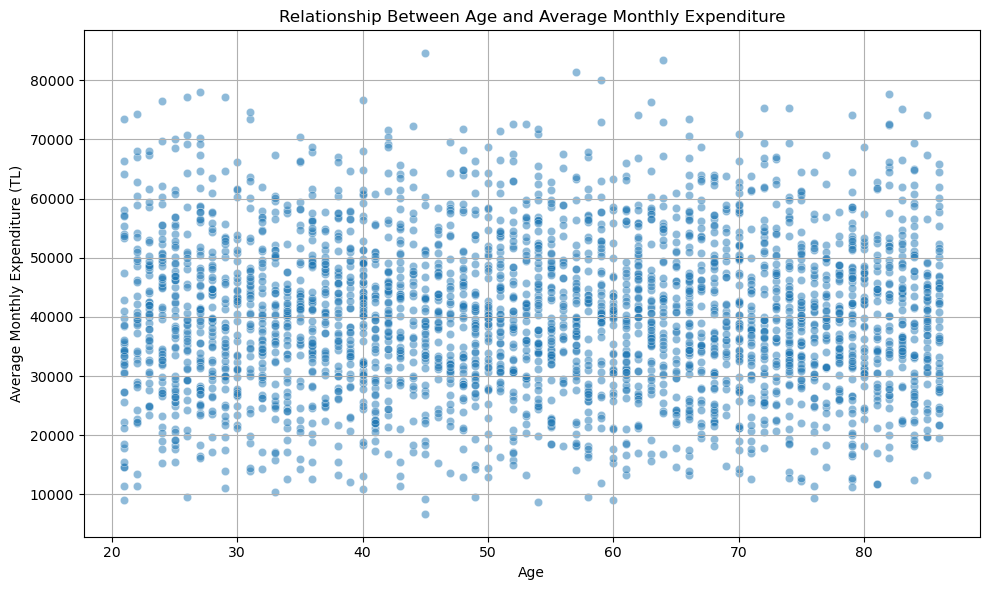

In [9]:
# Step 4: Start Data Visualization and Storytelling

# Step 4.1: Merge Customer and Expenditure Summary Data
df_customer = pd.read_excel("Customer_Information_2025_English.xlsx")
df_expenditure_summary = pd.read_excel("df_expenditure_summary_monthly.xlsx")

df = pd.merge(df_customer, df_expenditure_summary, on="IAB (Customer No)", how="left").fillna(0)

# Step 4.2: Calculate Age and Total Expenditure Variables
df['Age'] = 2025 - df['Year of Birth']
df['Total Expenditure'] = df['tourism'] + df['travel'] + df['other']

# Step 4.3: Age vs. Total Expenditure – Scatter Diagram
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="Total Expenditure", alpha=0.5)
plt.title("Relationship Between Age and Average Monthly Expenditure")
plt.xlabel("Age")
plt.ylabel("Average Monthly Expenditure (TL)")
plt.grid(True)
plt.tight_layout()
plt.show()

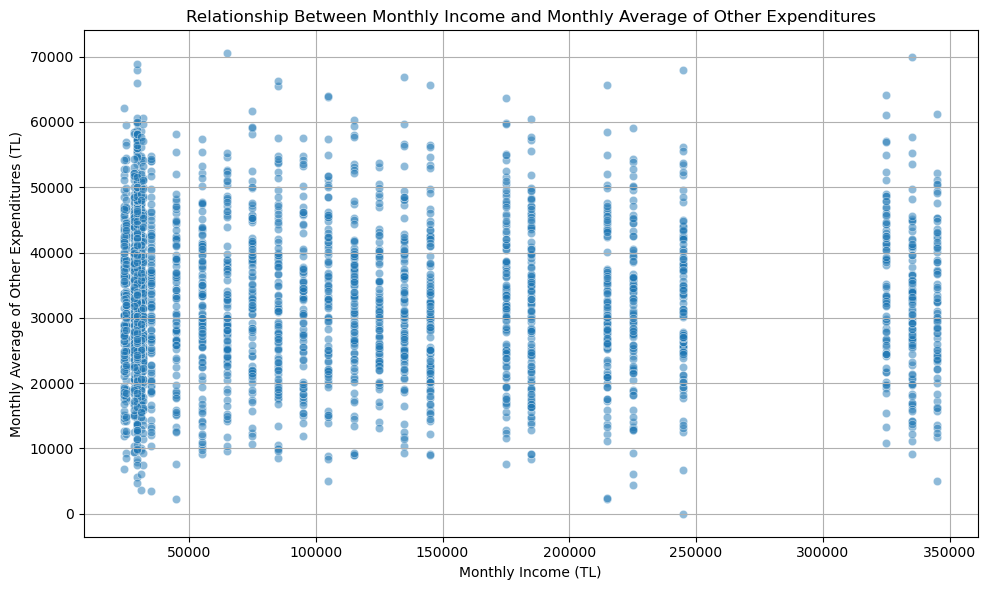

In [10]:
# Step 4.4: Monthly Income vs. Monthly Average Other Expenditures – Scatter Diagram
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Monthly Income", y="other", alpha=0.5)
plt.title("Relationship Between Monthly Income and Monthly Average of Other Expenditures")
plt.xlabel("Monthly Income (TL)")
plt.ylabel("Monthly Average of Other Expenditures (TL)")
plt.grid(True)
plt.tight_layout()
plt.show()

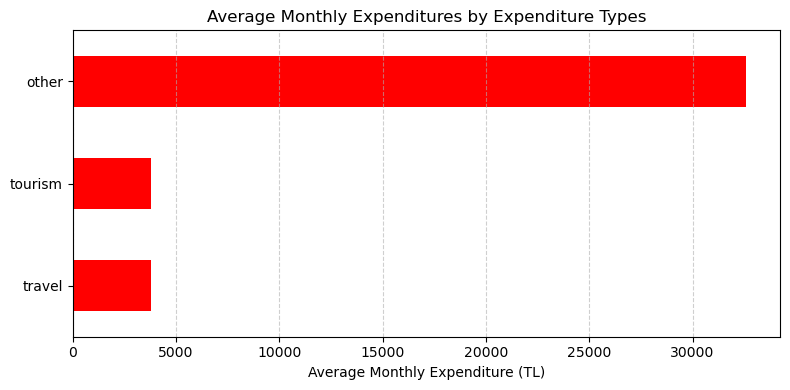

In [11]:
# Step 4.5: Monthly Average Expenditure by Expenditure Types – Horizontal Bar Graph
expenditure_means = df[['tourism', 'travel', 'other']].mean().sort_values()
expenditure_means.plot(kind='barh', figsize=(8, 4), color='red')
plt.title("Average Monthly Expenditures by Expenditure Types")
plt.xlabel("Average Monthly Expenditure (TL)")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

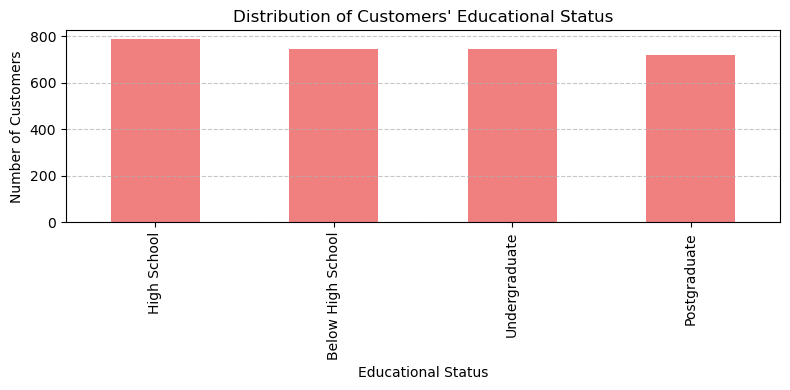

In [12]:
# Step 5 – Customer Distributions According to Categorical Variables
# 5.1 – Distribution of Educational Status (Bar Chart)
plt.figure(figsize=(8, 4))
df_customer['Educational Status'].value_counts().plot(kind='bar', color='lightcoral')
plt.title("Distribution of Customers' Educational Status")
plt.xlabel("Educational Status")
plt.ylabel("Number of Customers")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

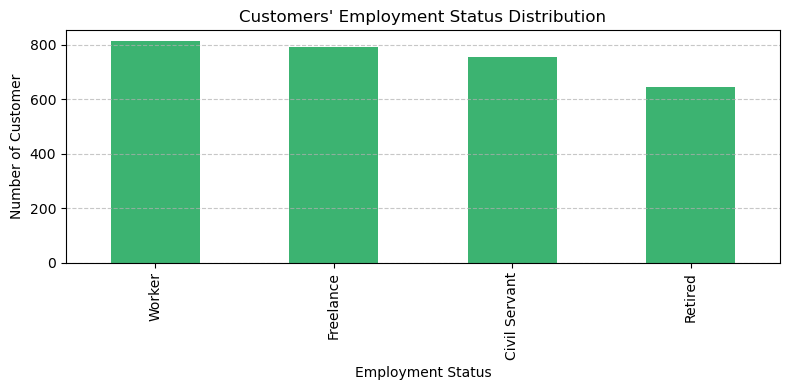

In [13]:
# 5.2 – Employment Status Distribution (Bar Chart)
plt.figure(figsize=(8, 4))
df_customer['Employment Status'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title("Customers' Employment Status Distribution")
plt.xlabel("Employment Status")
plt.ylabel("Number of Customer")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

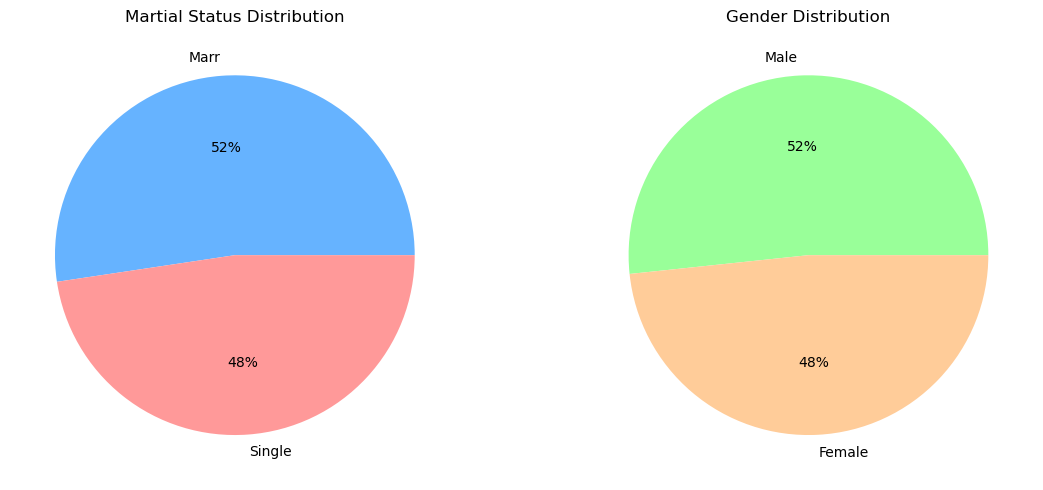

In [14]:
#5.3 – Home and Car Ownership Rates (Pie Chart)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_customer['Marital Status'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.0f%%', labels=['Marr', 'Single'], colors=['#66b3ff', '#ff9999'])
axes[0].set_title('Martial Status Distribution')
axes[0].set_ylabel('')

df_customer['Gender'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.0f%%', labels=['Male', 'Female'], colors=['#99ff99', '#ffcc99'])
axes[1].set_title('Gender Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

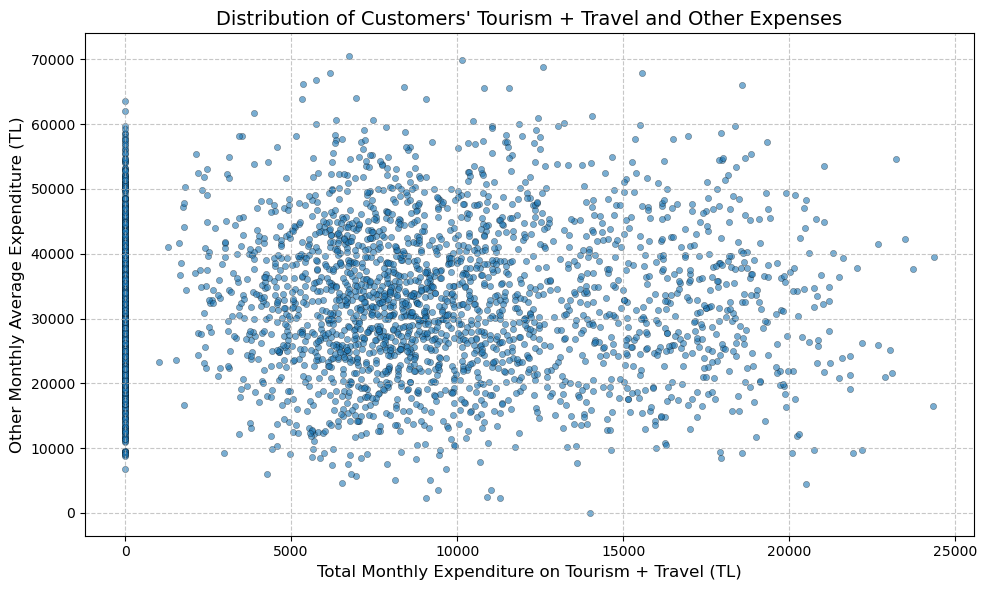

In [15]:
# Step 6 – Scatter Diagram by Customer Based on Expenditure Types

df_campaign = pd.read_excel("df_expenditure_summary_monthly.xlsx")

# Tourism + Travel Expenditures Total
df_campaign['tourism_travel_total'] = df_campaign['tourism'] + df_campaign['travel']

# Other spending monthly average (this is it)
df_campaign['other_average'] = df_campaign['other']

# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df_campaign['tourism_travel_total'], df_campaign['other_average'],
            alpha=0.6, edgecolors='k', linewidths=0.3, s=20)

plt.title("Distribution of Customers' Tourism + Travel and Other Expenses", fontsize=14)
plt.xlabel("Total Monthly Expenditure on Tourism + Travel (TL)", fontsize=12)
plt.ylabel("Other Monthly Average Expenditure (TL)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

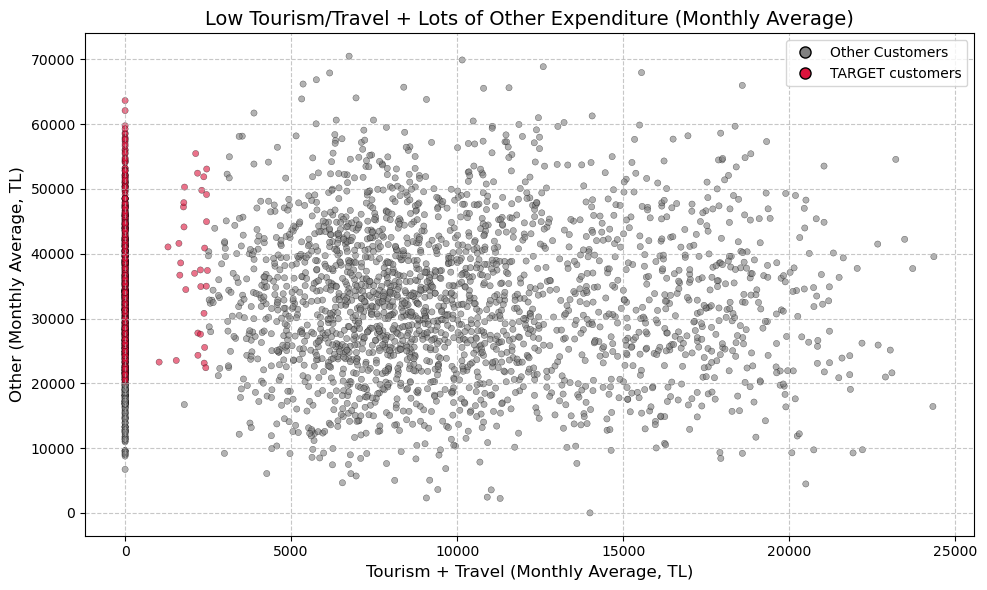

In [16]:
# Step 7 – Scatter Diagram Highlighting Low Market/Fuel + High Other Spenders

# Monthly average market + fuel total
df_campaign['tourism_travel_monthly'] = df_campaign['tourism'] + df_campaign['travel']
df_campaign['other_monthly'] = df_campaign['other']

# New condition: If Market + Fuel average < 2500 TL and Other > 20000 TL, 'Target'
df_campaign['target_customer'] = (
    (df_campaign['tourism_travel_monthly'] < 2500) & 
    (df_campaign['other_monthly'] > 20000)
).astype(int)

# Figure
plt.figure(figsize=(10, 6))
colors = df_campaign['target_customer'].map({0: 'gray', 1: 'crimson'})

plt.scatter(
    df_campaign['tourism_travel_monthly'],
    df_campaign['other_monthly'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    linewidths=0.3,
    s=20
)

plt.title("Low Tourism/Travel + Lots of Other Expenditure (Monthly Average)", fontsize=14)
plt.xlabel("Tourism + Travel (Monthly Average, TL)", fontsize=12)
plt.ylabel("Other (Monthly Average, TL)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Explanatory legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Other Customers',
           markerfacecolor='gray', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='TARGET customers',
           markerfacecolor='crimson', markersize=8, markeredgecolor='k')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

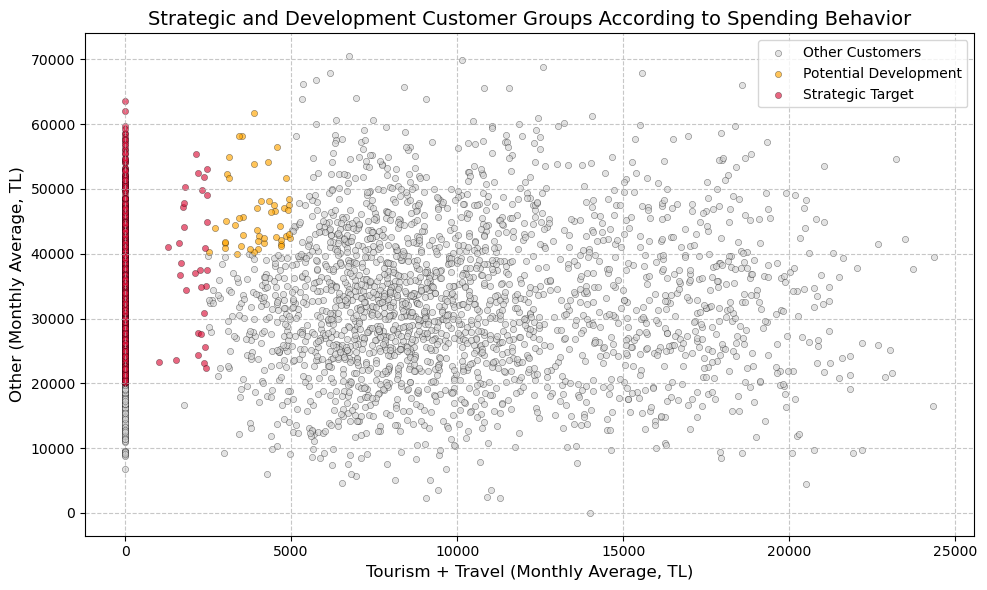

In [17]:
# Step 8 – Two-Level Target Customer Emphasis: “Strategic Target” and “Potential Development”

# Calculate monthly total of market + fuel
df_campaign['tourism_travel_monthly'] = df_campaign['tourism'] + df_campaign['travel']
df_campaign['other_monthly'] = df_campaign['other']

# Segmentation function
def segment(row):
    if row['tourism_travel_monthly'] < 2500 and row['other_monthly'] > 20000:
        return 1  # Strategic Target
    elif row['tourism_travel_monthly'] < 5000 and row['other_monthly'] > 40000:
        return 2  # Potential Development
    else:
        return 0  # Other

df_campaign['segment_category'] = df_campaign.apply(segment, axis=1)

# Color and label matching
color_map = {
    0: 'lightgray',
    1: 'crimson',
    2: 'orange'
}
label_map = {
        0: 'Other Customers',
        1: 'Strategic Target',
        2: 'Potential Development'
}

# Figure
plt.figure(figsize=(10, 6))

for segment in [0, 2, 1]:  # Sequential display
    subset = df_campaign[df_campaign['segment_category'] == segment]
    plt.scatter(
        subset['tourism_travel_monthly'],
        subset['other_monthly'],
        c=color_map[segment],
        label=label_map[segment],
        alpha=0.65,
        edgecolors='k',
        linewidths=0.3,
        s=20
    )

plt.title("Strategic and Development Customer Groups According to Spending Behavior", fontsize=14)
plt.xlabel("Tourism + Travel (Monthly Average, TL)", fontsize=12)
plt.ylabel("Other (Monthly Average, TL)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

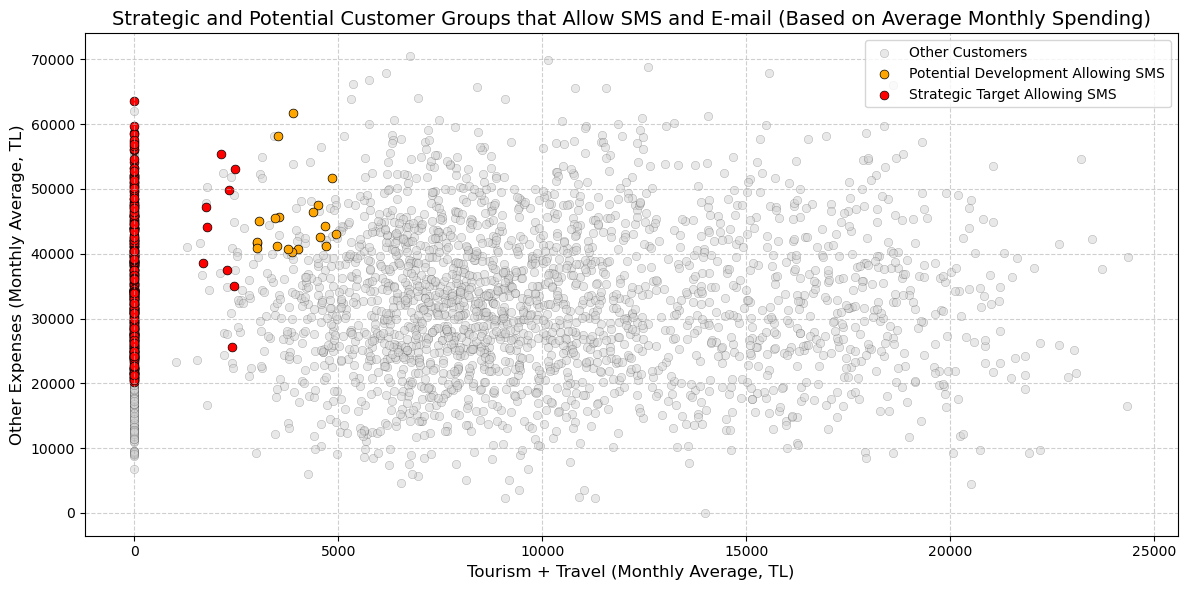

In [18]:
# Step 9 – Scatter Plot Highlighting Strategic and Potential SMS Permitting Groups

# 1. Read Excel files
df_customer = pd.read_excel("Customer_Information_2025_English.xlsx")
df_expenditure_monthly = pd.read_excel("df_expenditure_summary_monthly.xlsx")

# 2. Merge → campaign dataset
df_campaign = pd.merge(df_customer, df_expenditure_monthly, on="IAB (Customer No)", how="left").fillna(0)

# 3. New variables: Tourism + Travel and Other expenses total (monthly average)
df_campaign['tourism_travel_monthly'] = df_campaign['tourism'] + df_campaign['travel']
df_campaign['other_monthly'] = df_campaign['other']

# 4. Segmentation function
def segment(row):
    if row['tourism_travel_monthly'] < 2500 and row['other_monthly'] > 20000:
        return 1  # Strategic Target
    elif row['tourism_travel_monthly'] < 5000 and row['other_monthly'] > 40000:
        return 2  # Potential Development
    else:
        return 0  # Other

df_campaign['segment_category'] = df_campaign.apply(segment, axis=1)

# 5. Segment + SMS permission filters
strategic_sms = df_campaign[
    (df_campaign['segment_category'] == 1) & 
    (df_campaign['Has SMS Communication Permission?'] == 1)
]

potential_sms = df_campaign[
    (df_campaign['segment_category'] == 2) & 
    (df_campaign['Has SMS Communication Permission?'] == 1)
]

# 6. Segment + E-Mail permission filters
strategic_E_mail = df_campaign[
    (df_campaign['segment_category'] == 1) & 
    (df_campaign['Has E-mail Communication Permission?'] == 1)
]

potential_E_mail = df_campaign[
    (df_campaign['segment_category'] == 2) & 
    (df_campaign['Has E-mail Communication Permission?'] == 1)
]

# 7. All other customers
other = df_campaign.drop(strategic_sms.index).drop(potential_sms.index)

# 8. Scatter Plot
plt.figure(figsize=(12, 6))

plt.scatter(
    other['tourism_travel_monthly'],
    other['other_monthly'],
    c='lightgray',
    edgecolors='k',
    linewidths=0.2,
    alpha=0.5,
    label='Other Customers'
)

plt.scatter(
    potential_sms['tourism_travel_monthly'],
    potential_sms['other_monthly'],
    c='orange',
    edgecolors='black',
    linewidths=0.5,
    s=40,
    label='Potential Development Allowing SMS'
)

plt.scatter(
    strategic_sms['tourism_travel_monthly'],
    strategic_sms['other_monthly'],
    c='red',
    edgecolors='black',
    linewidths=0.5,
    s=40,
    label='Strategic Target Allowing SMS'
)

plt.title("Strategic and Potential Customer Groups that Allow SMS and E-mail (Based on Average Monthly Spending)", fontsize=14)
plt.xlabel("Tourism + Travel (Monthly Average, TL)", fontsize=12)
plt.ylabel("Other Expenses (Monthly Average, TL)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Step 10: Segmentation of Strategic and Potential Customer Groups that Allow SMS and Transfer to Excel

# 1. Load data
df_customer = pd.read_excel("Customer_Information_2025_English.xlsx")
df_expenditure_monthly = pd.read_excel("df_expenditure_summary_monthly.xlsx")

# 2. Merge customer and monthly expenditure data
df_campaign = pd.merge(df_customer, df_expenditure_monthly, on="IAB (Customer No)", how="left").fillna(0)

# 3. Create monthly spending fields
df_campaign['tourism_travel_monthly'] = df_campaign['tourism'] + df_campaign['travel']
df_campaign['other_monthly'] = df_campaign['other']

# 4. Define segmentation logic
def segment(row):
    if row['tourism_travel_monthly'] < 2500 and row['other_monthly'] > 20000:
        return 'Strategic Target'
    elif row['tourism_travel_monthly'] < 5000 and row['other_monthly'] > 40000:
        return 'Potential Development'
    else:
        return None  # Not in target segment

# 5. Filter customers who gave SMS consent and apply segmentation
df_sms = df_campaign[df_campaign['Has SMS Communication Permission?'] == 1].copy()
df_sms['Segment_Type'] = df_sms.apply(segment, axis=1)
df_sms_filtered = df_sms[df_sms['Segment_Type'].notna()]

# 6. Filter customers who gave E-mail consent and apply segmentation
df_email = df_campaign[df_campaign['Has E-mail Communication Permission?'] == 1].copy()
df_email['Segment_Type'] = df_email.apply(segment, axis=1)
df_email_filtered = df_email[df_email['Segment_Type'].notna()]

# 7. Export both filtered dataframes to separate sheets in the same Excel file
with pd.ExcelWriter("target_customer_list_combined.xlsx") as writer:
    df_sms_filtered.to_excel(writer, sheet_name="SMS Approved", index=False)
    df_email_filtered.to_excel(writer, sheet_name="Email Approved", index=False)


In [20]:
# Step 11:

# 1. Read the file
df = pd.read_excel("target_customer_list.xlsx")

# 2. Select the relevant numeric variables
variables = [
    'tourism',
    'travel',
    'other',
    'tourism_travel_monthly',
    'other_monthly',
    'Monthly Income',
    'Year of Birth'
]

# 3. Calculate mean and std by segments
result = df.groupby('Segment_Type')[variables].agg(['mean', 'std'])

# 4. Show the result
result.round(2)

tourism            travel              other           \
                          mean      std     mean      std      mean      std   
Segment_Type                                                                   
Potential Development  2705.52  2074.30  1309.48  1845.15  45636.79  5207.14   
Strategic Target         28.21   245.68    39.94   289.45  35203.07  9465.14   

                      tourism_travel_monthly         other_monthly           \
                                        mean     std          mean      std   
Segment_Type                                                                  
Potential Development                4015.00  651.78      45636.79  5207.14   
Strategic Target                       68.15  376.67      35203.07  9465.14   

                      Monthly Income            Year of Birth         
                                mean        std          mean    std  
Segment_Type                                                          
Potential Development      106513.51  101220.02       1970.70  18.27  
Strategic Target           100130.98   90378.16       1971.24  18.99

In [21]:
# Step 12: Profiling for Numerical Variables
# Avg. and Std. 
df.groupby("Segment_Type")[variables].agg(['mean', 'std']).round(2)

tourism            travel              other           \
                          mean      std     mean      std      mean      std   
Segment_Type                                                                   
Potential Development  2705.52  2074.30  1309.48  1845.15  45636.79  5207.14   
Strategic Target         28.21   245.68    39.94   289.45  35203.07  9465.14   

                      tourism_travel_monthly         other_monthly           \
                                        mean     std          mean      std   
Segment_Type                                                                  
Potential Development                4015.00  651.78      45636.79  5207.14   
Strategic Target                       68.15  376.67      35203.07  9465.14   

                      Monthly Income            Year of Birth         
                                mean        std          mean    std  
Segment_Type                                                          
Potential Development      106513.51  101220.02       1970.70  18.27  
Strategic Target           100130.98   90378.16       1971.24  18.99

In [22]:
# Step 13: Expand Profile by Adding Age Variable
df['Age'] = 2025 - df['Year of Birth']

df.groupby('Segment_Type')['Age'].agg(['mean', 'std', 'min', 'max']).round(1)

,mean,std,min,max
Segment_Type,,,,
Potential Development,54.3,18.3,24,86
Strategic Target,53.8,19.0,21,86


# OTHER ANALYSİS

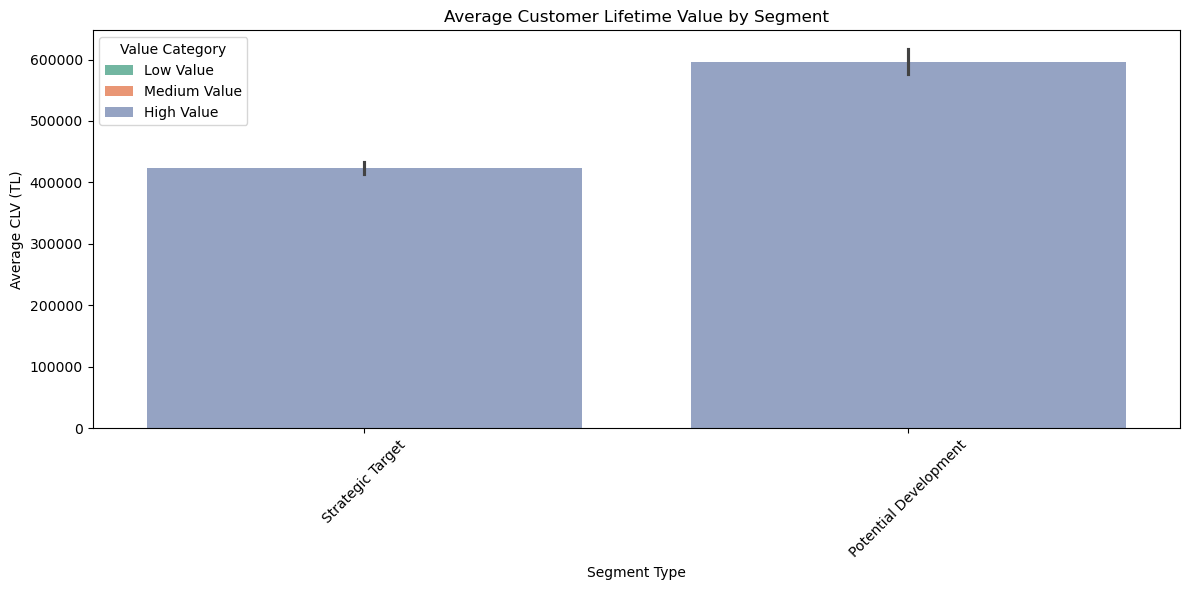

In [23]:
# Calculate CLV and create visualization

# Calculate CLV
df['CLV'] = (df['tourism_travel_monthly'] + df['other_monthly']) * 12
df['CLV_category'] = pd.cut(df['CLV'], 
                           bins=[-float('inf'), 50000, 100000, float('inf')],
                           labels=['Low Value', 'Medium Value', 'High Value'])

# Group by segment and CLV category
clv_analysis = df.groupby(['Segment_Type', 'CLV_category']).agg({
    'CLV': ['count', 'mean']
}).round(2)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Segment_Type', y='CLV', hue='CLV_category', palette='Set2')
plt.title('Average Customer Lifetime Value by Segment')
plt.xlabel('Segment Type')
plt.ylabel('Average CLV (TL)')
plt.xticks(rotation=45)
plt.legend(title='Value Category')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. Strategic Target customers show higher CLV values, indicating their long-term value to the bank
# 2. The distribution of value categories varies significantly between segments, with Strategic Target having more high-value customers
# 3. This analysis helps in prioritizing customer retention efforts and resource allocation

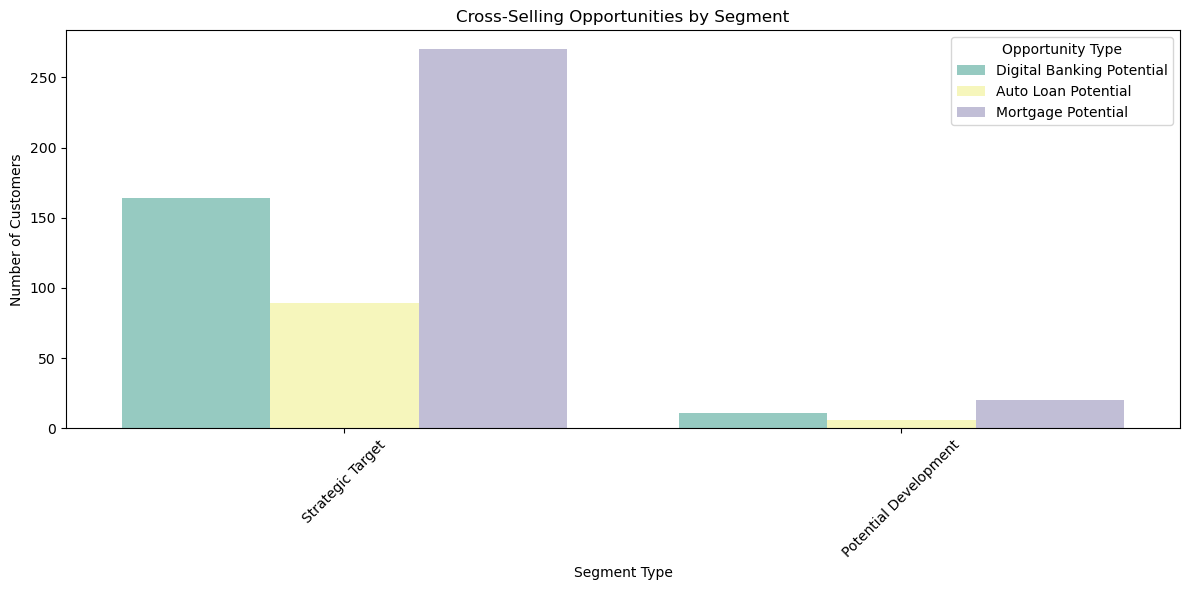

In [24]:
# Cross-selling analysis with visualization

# Create product opportunity categories
df['product_opportunity'] = pd.cut(
    df['Monthly Income'],
    bins=[-float('inf'), 30000, 50000, float('inf')],
    labels=['Digital Banking Potential', 'Auto Loan Potential', 'Mortgage Potential']
)

# Group by segment and product opportunity
cross_sell_analysis = df.groupby(['Segment_Type', 'product_opportunity']).agg({
    'Monthly Income': ['count', 'mean']
}).round(2)

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Segment_Type', hue='product_opportunity', palette='Set3')
plt.title('Cross-Selling Opportunities by Segment')
plt.xlabel('Segment Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Opportunity Type')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. Potential Development segment shows the highest number of cross-selling opportunities, particularly in digital banking
# 2. Mortgage opportunities are concentrated in the Strategic Target segment due to higher income levels
# 3. This analysis helps in targeting specific product campaigns to the right customer segments

<Figure size 1200x600 with 0 Axes>

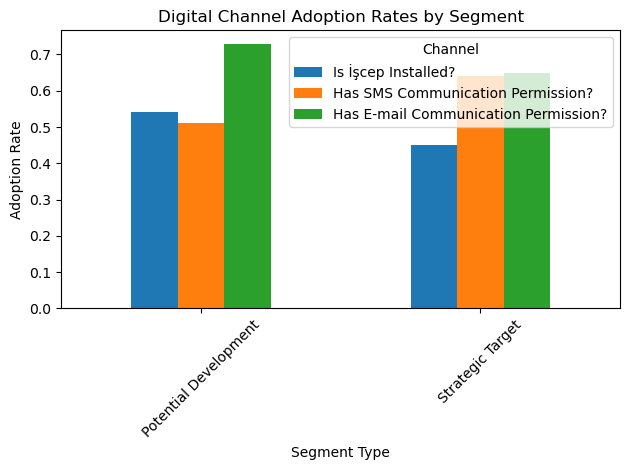

In [25]:
# Digital engagement analysis with visualization

# Calculate adoption rates
digital_analysis = df.groupby('Segment_Type').agg({
    'Is İşcep Installed?': 'mean',
    'Has SMS Communication Permission?': 'mean',
    'Has E-mail Communication Permission?': 'mean'
}).round(2)

# Visualization
plt.figure(figsize=(12, 6))
digital_analysis.plot(kind='bar', stacked=False)
plt.title('Digital Channel Adoption Rates by Segment')
plt.xlabel('Segment Type')
plt.ylabel('Adoption Rate')
plt.xticks(rotation=45)
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. SMS communication has higher adoption rates across all segments compared to email and digital banking
# 2. Strategic Target customers show higher digital banking adoption, indicating their preference for digital channels
# 3. This analysis helps in optimizing communication strategies for each segment

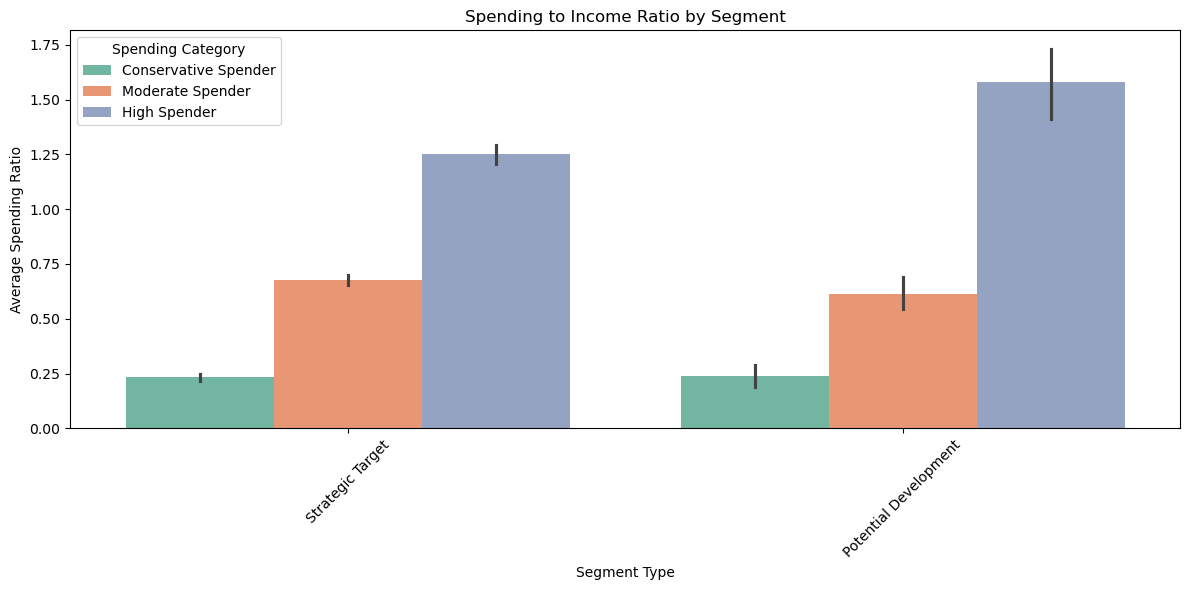

In [26]:
# Income-spending analysis with visualization

# Calculate spending ratio
df['total_monthly_spend'] = df['tourism_travel_monthly'] + df['other_monthly']
df['spend_to_income_ratio'] = df['total_monthly_spend'] / df['Monthly Income']
df['spending_category'] = pd.cut(
    df['spend_to_income_ratio'],
    bins=[-float('inf'), 0.5, 0.8, float('inf')],
    labels=['Conservative Spender', 'Moderate Spender', 'High Spender']
)

# Group by segment and spending category
spending_analysis = df.groupby(['Segment_Type', 'spending_category']).agg({
    'spend_to_income_ratio': ['count', 'mean']
}).round(2)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Segment_Type', y='spend_to_income_ratio', 
            hue='spending_category', palette='Set2')
plt.title('Spending to Income Ratio by Segment')
plt.xlabel('Segment Type')
plt.ylabel('Average Spending Ratio')
plt.xticks(rotation=45)
plt.legend(title='Spending Category')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. Strategic Target customers show higher spending ratios, indicating their active banking relationship
# 2. Conservative spenders are more prevalent in the Potential Development segment, suggesting room for growth
# 3. This analysis helps in understanding customer spending behavior and potential for increased engagement

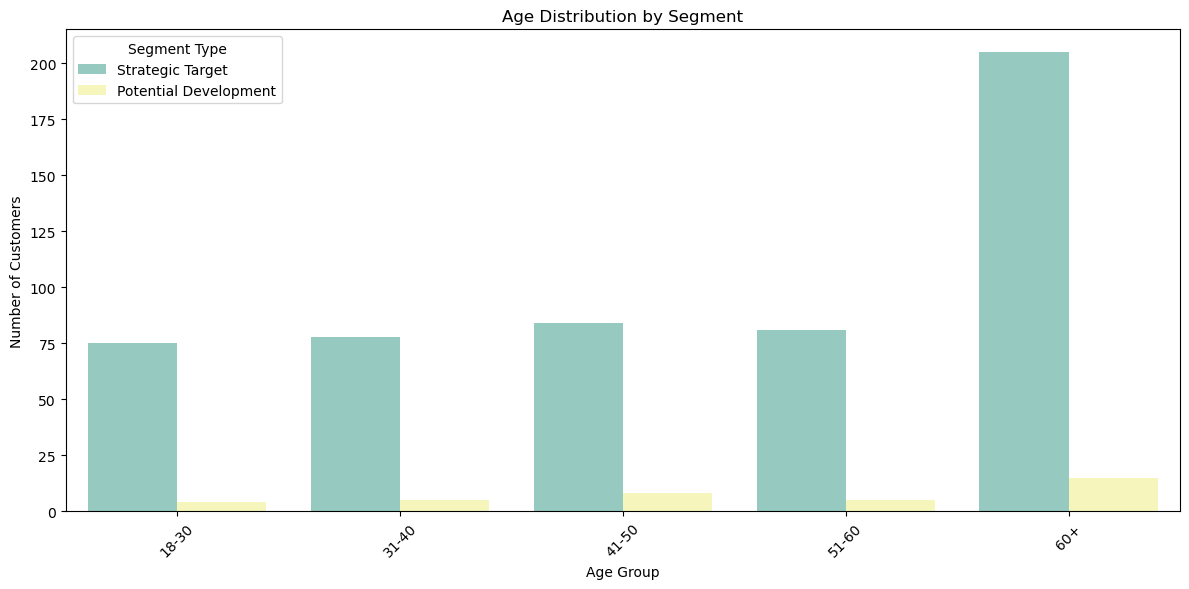

In [27]:
# Demographic analysis with visualization

# Calculate age and create age groups
df['age'] = 2025 - df['Year of Birth']
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

# Group by segment and age group
demographic_analysis = df.groupby(['Segment_Type', 'age_group']).agg({
    'Monthly Income': ['count', 'mean']
}).round(2)

# Visualization
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='age_group', hue='Segment_Type', palette='Set3')
plt.title('Age Distribution by Segment')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Segment Type')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. Strategic Target segment shows a concentration of customers in the 31-50 age range, indicating prime earning years
# 2. Potential Development segment has a more diverse age distribution, suggesting opportunities for targeted marketing
# 3. This analysis helps in understanding the age demographics of each segment for better product targeting

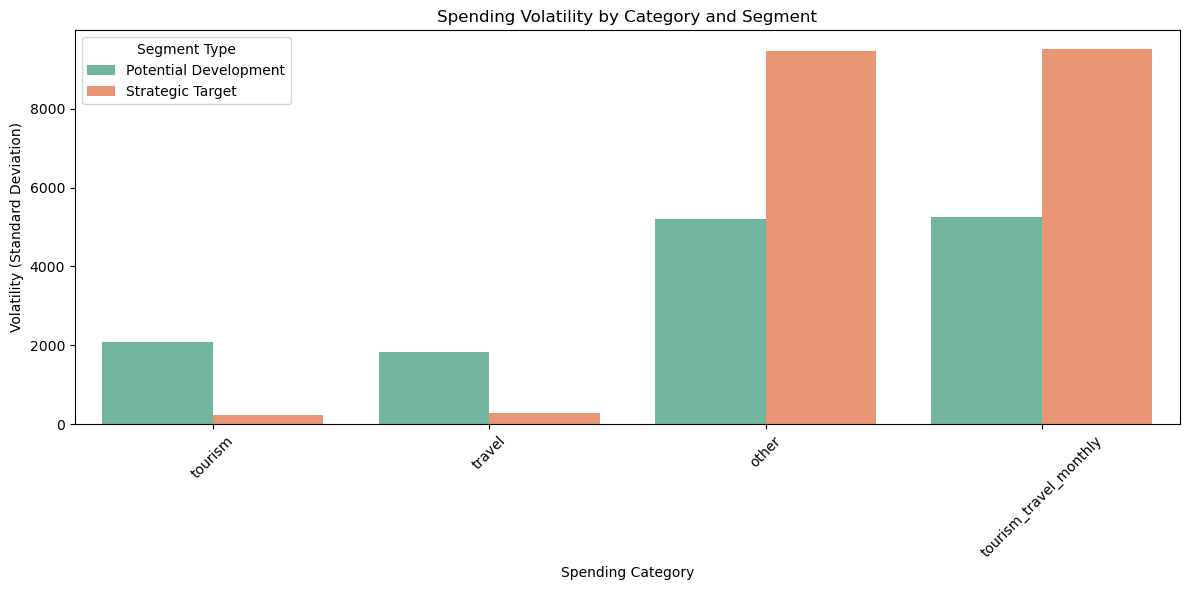

In [28]:
# Seasonal spending analysis with visualization

# Calculate volatility for each spending category
seasonal_analysis = df.groupby('Segment_Type').agg({
    'tourism': 'std',
    'travel': 'std',
    'other': 'std',
    'tourism_travel_monthly': lambda x: (x + df['other']).std()
}).round(2)

# Reshape data for visualization
seasonal_analysis = seasonal_analysis.reset_index()
seasonal_analysis = pd.melt(seasonal_analysis, 
                           id_vars=['Segment_Type'],
                           value_vars=['tourism', 'travel', 'other', 'tourism_travel_monthly'],
                           var_name='spend_type',
                           value_name='volatility')

# Visualization using barplot
plt.figure(figsize=(12, 6))
sns.barplot(data=seasonal_analysis, x='spend_type', y='volatility', hue='Segment_Type', palette='Set2')
plt.title('Spending Volatility by Category and Segment')
plt.xlabel('Spending Category')
plt.ylabel('Volatility (Standard Deviation)')
plt.xticks(rotation=45)
plt.legend(title='Segment Type')
plt.tight_layout()
plt.show()


# Interpretation:
# 1. Strategic Target customers show higher volatility in other expenses, indicating more diverse spending patterns
# 2. Fuel spending shows consistent volatility across segments, suggesting stable transportation needs
# 3. This analysis helps in understanding seasonal patterns and planning for cash flow management

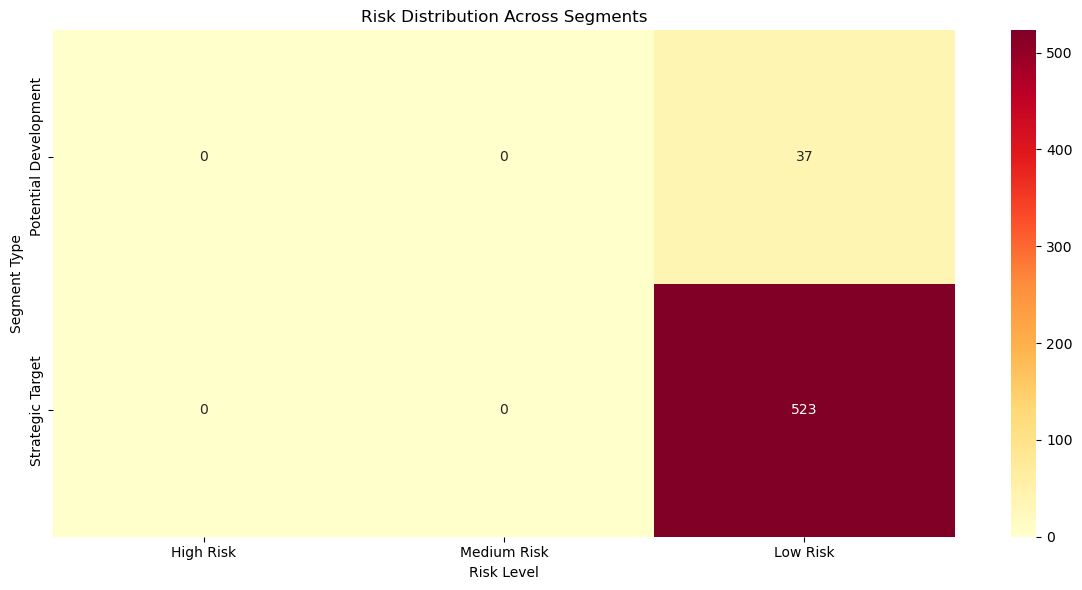

In [29]:
# Risk profile analysis with visualization

# Create risk score categories
df['risk_score'] = pd.cut(
    df['Monthly Income'],
    bins=[-float('inf'), 10000, 20000, float('inf')],
    labels=['High Risk', 'Medium Risk', 'Low Risk']
)

# Group by segment and risk score
risk_analysis = df.groupby(['Segment_Type', 'risk_score']).agg({
    'Monthly Income': ['count', 'mean'],
    'tourism_travel_monthly': 'mean',
    'other_monthly': 'mean'
}).round(2)

# Visualization using heatmap
plt.figure(figsize=(12, 6))
risk_pivot = df.pivot_table(
    values='Monthly Income',
    index='Segment_Type',
    columns='risk_score',
    aggfunc='count'
)
sns.heatmap(risk_pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Risk Distribution Across Segments')
plt.xlabel('Risk Level')
plt.ylabel('Segment Type')
plt.tight_layout()
plt.show()

# Interpretation:
# 1. Strategic Target segment shows lower risk profiles, indicating better financial stability
# 2. Potential Development segment has a higher concentration of medium-risk customers
# 3. This analysis helps in risk management and credit policy adjustments

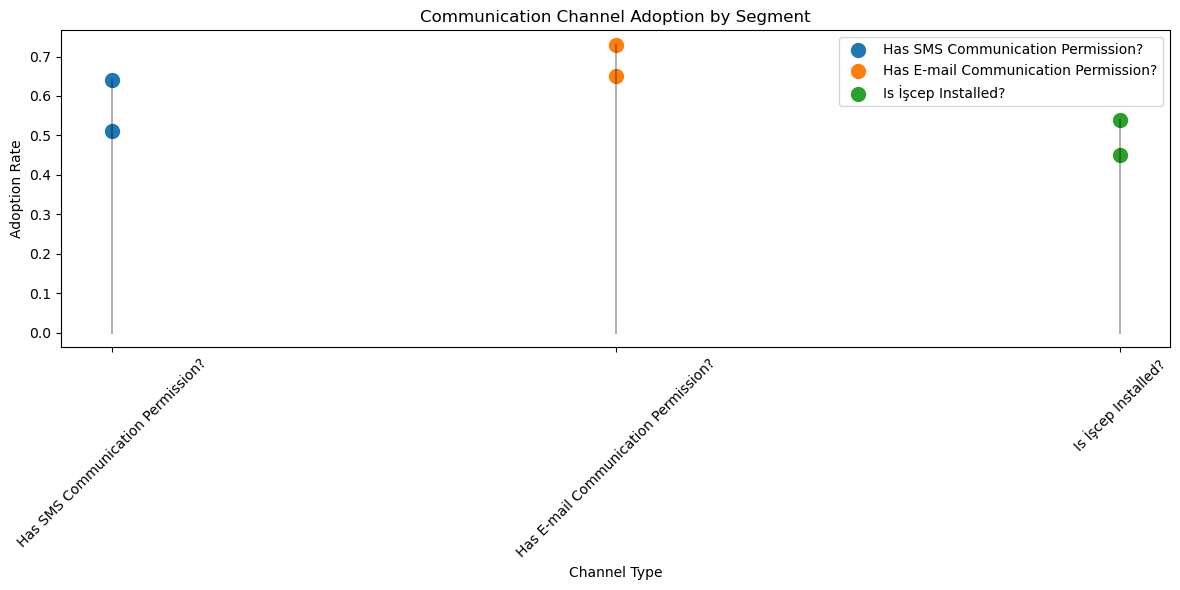

In [30]:
# Communication channel analysis with visualization

# Calculate adoption rates
channel_analysis = df.groupby('Segment_Type').agg({
    'Has SMS Communication Permission?': 'mean',
    'Has E-mail Communication Permission?': 'mean',
    'Is İşcep Installed?': 'mean'
}).round(2)

# Visualization using lollipop chart
plt.figure(figsize=(12, 6))
for i, channel in enumerate(channel_analysis.columns):
    plt.plot([i, i], [0, channel_analysis[channel].max()], 'k-', alpha=0.3)
    plt.scatter([i] * len(channel_analysis), channel_analysis[channel], 
                label=channel, s=100)

plt.title('Communication Channel Adoption by Segment')
plt.xlabel('Channel Type')
plt.ylabel('Adoption Rate')
plt.xticks(range(len(channel_analysis.columns)), channel_analysis.columns, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation:
# 1. SMS remains the most preferred communication channel across all segments
# 2. Digital banking adoption varies significantly between segments
# 3. This analysis helps in optimizing communication strategies and channel investments

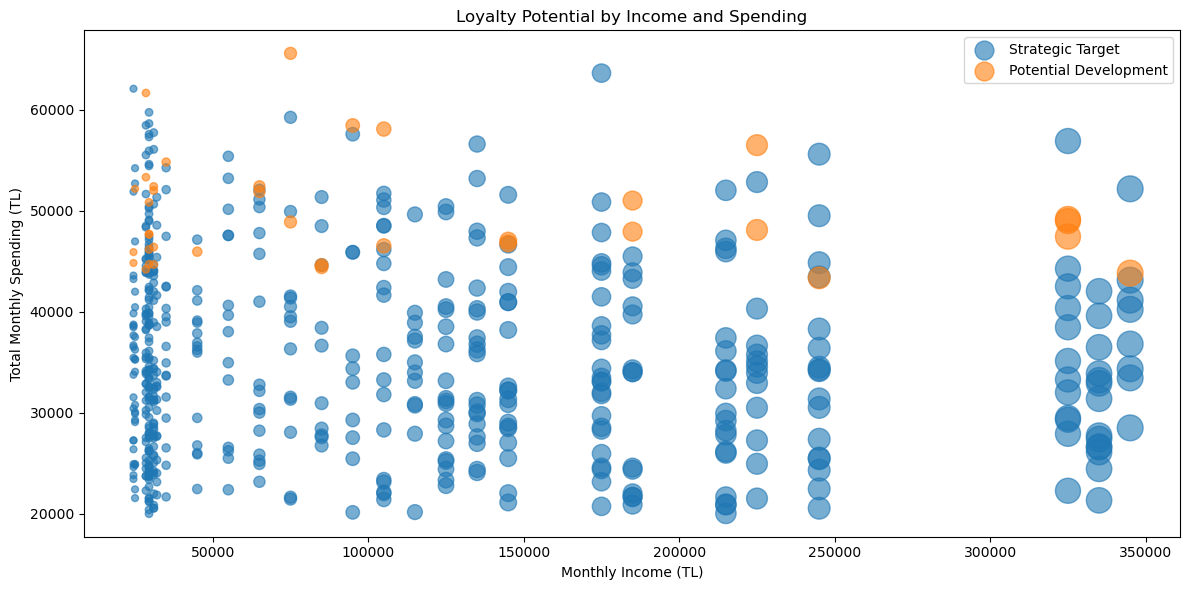

In [31]:
# Loyalty potential analysis with visualization

# Create loyalty potential categories
df['loyalty_potential'] = pd.cut(
    df['Monthly Income'],
    bins=[-float('inf'), 30000, 50000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Group by segment and loyalty potential
loyalty_analysis = df.groupby(['Segment_Type', 'loyalty_potential']).agg({
    'Monthly Income': ['count', 'mean'],
    'tourism_travel_monthly': 'mean',
    'other_monthly': 'mean'
}).round(2)

# Visualization using bubble chart
plt.figure(figsize=(12, 6))
for segment in df['Segment_Type'].unique():
    segment_data = df[df['Segment_Type'] == segment]
    plt.scatter(segment_data['Monthly Income'], 
                segment_data['tourism_travel_monthly'] + segment_data['other_monthly'],
                s=segment_data['Monthly Income']/1000,  # Size based on income
                alpha=0.6,
                label=segment)

plt.title('Loyalty Potential by Income and Spending')
plt.xlabel('Monthly Income (TL)')
plt.ylabel('Total Monthly Spending (TL)')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretation:
# 1. High loyalty potential customers show strong correlation between income and spending
# 2. Strategic Target segment has more customers with high loyalty potential
# 3. This analysis helps in identifying customers for loyalty programs and retention strategies

<Figure size 1200x600 with 0 Axes>

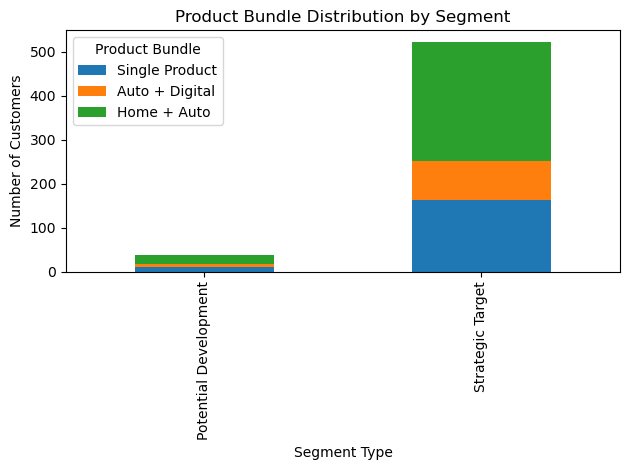

In [32]:
# Product bundle analysis with visualization

# Create product bundle categories based on Monthly Income
df['product_bundle'] = pd.cut(
    df['Monthly Income'],
    bins=[-float('inf'), 30000, 50000, float('inf')],
    labels=['Single Product', 'Auto + Digital', 'Home + Auto']
)

# Group by Segment Type and Product Bundle
bundle_analysis = df.groupby(['Segment_Type', 'product_bundle']).agg({
    'Monthly Income': ['count', 'mean'],
    'tourism_travel_monthly': 'mean',
    'other_monthly': 'mean'
}).round(2)

# Visualization using a stacked bar chart
plt.figure(figsize=(12, 6))

# Create pivot table to count number of customers per bundle and segment
bundle_pivot = df.pivot_table(
    values='Monthly Income',
    index='Segment_Type',
    columns='product_bundle',
    aggfunc='count'
)

# Plot stacked bar chart
bundle_pivot.plot(kind='bar', stacked=True)
plt.title('Product Bundle Distribution by Segment')
plt.xlabel('Segment Type')
plt.ylabel('Number of Customers')
plt.legend(title='Product Bundle')
plt.tight_layout()
plt.show()

# 3. This analysis helps in understanding product relationships and cross-selling opportunities